# Discrete Fourier Series (DFS) — Manual Implementation (No FFT)

**Course:** Signals / DSP  
**Homework:** DFS by correlation / inner products (`np.sum` / `np.dot`)  
**Student:** *(fill in)*  
**Date:** *(fill in)*

---

## Objective

Implement the **Discrete Fourier Series (DFS)** for **periodic discrete-time** signals.

You must:

1. Construct **three** periodic discrete signals (one period only).
2. Compute DFS coefficients **manually** using the definition (correlation / inner product).
3. Reconstruct each signal from its coefficients.
4. Compare original vs reconstructed signals.
5. Report reconstruction error.

---

## Restrictions (IMPORTANT)

 Allowed:
- `numpy`, `matplotlib`
- `np.sum`, `np.dot`
- `np.exp`, complex numbers, loops (if you want)

 Not allowed:
- `np.fft.fft`, `np.fft.ifft`, or any FFT/DFT helper
- Any library function that directly returns Fourier coefficients


## DFS Definitions (use these)

We work with one period of a discrete-time periodic signal:
- Period: $$N$$
- Samples: $$n = 0,1,\dots,N-1$$
- Signal values: $$x[n]$$

### Complex exponential basis
$$
\phi_k[n] = e^{j\frac{2\pi}{N}kn},\quad k=0,1,\dots,N-1
$$

### Analysis (coefficients)
$$
X[k] = \frac{1}{N}\sum_{n=0}^{N-1} x[n]\;e^{-j\frac{2\pi}{N}kn}
$$

### Synthesis (reconstruction)
$$
\hat{x}[n] = \sum_{k=0}^{N-1} X[k]\;e^{j\frac{2\pi}{N}kn}
$$

### Reconstruction error (RMSE)
$$
\mathrm{RMSE} = \sqrt{\frac{1}{N}\sum_{n=0}^{N-1}\left|x[n]-\hat{x}[n]\right|^2}
$$

**Implementation requirement:** compute the sums using `np.sum` or `np.dot`.


In [1]:
# === Imports ===
import numpy as np
import matplotlib.pyplot as plt

# Make plots a bit larger for readability (optional)
plt.rcParams["figure.figsize"] = (10, 4)

# For reproducibility (only matters if you add noise later)
np.random.seed(0)


## Deliverables (what you must submit)

For each of the three signals (A, B, C), include:

1) A plot of the signal over one period: $$x[n]$$, $$n=0..N-1$$  
2) A stem/bar plot of the magnitude spectrum: $$|X[k]|$$  
3) A plot of the phase spectrum: $$angle X[k]$$  
4) A plot comparing $$x[n]$$ and $$\hat{x}[n]$$ over one period  
5) RMSE value and 2–4 sentences of interpretation

---

## Signals to analyze

You must implement all DFS for **three different periods**:
N1 = 16
N2 = 32
N3 = 64

### Signal A — Square wave
One period definition:
- $$x_A[n] = 1$$ for $$0 \le n < N_1/2$$
- $$x_A[n] = -1$$ for $$N_1/2 \le n < N_1$$

### Signal B — Triangle wave
Build a discrete triangle over one period, peak amplitude 1 (or rescale to $$[-1,1]$$).

#Signal C — Sum of sinusoids
$$
x_C[n] =
0.8\cos\left(2\pi\frac{1}{N}n\right)
+ 0.4\sin\left(2\pi\frac{2}{N}n + 0.3\right)
+ 0.2\cos\left(2\pi\frac{3}{N}n - 0.8\right)
$$

## 1) Datos del estudiante

Mostrando nombre y grupo de los desarrolladores

In [2]:
# === Datos del estudiante ===
NOMBRE1 = "Carmona Ayala Mariana Zoe (319018129)"
NOMBRE2 = "Zarco Romero José Alberto (319087563)"
GRUPO = "4"

print("Nombre 1:", NOMBRE1)
print("Nombre 2:", NOMBRE2)
print("Grupo:", GRUPO)


Nombre 1: Carmona Ayala Mariana Zoe (319018129)
Nombre 2: Zarco Romero José Alberto (319087563)
Grupo: 4


In [5]:
# === TODO 1: DFS (Analysis) ===
def dfs(x):
    """
    Compute DFS coefficients X[k] for a single-period signal x[n].

    Parameters
    ----------
    x : np.ndarray, shape (N,)
        One period of the signal (n=0..N-1). Can be real or complex.

    Returns
    -------
    X : np.ndarray, shape (N,), dtype=complex
        DFS coefficients X[k] = (1/N) * sum_n x[n] * exp(-j*2*pi*k*n/N)
    """
    N = len(x) # Obtenemos muestras de la señal
    n = np.arange(N) # Indices de tiempo
    X = np.zeros(N, dtype=complex) # Guardamos parte real y parte imagianria

    # Para cada frecuencia
    for k in range(N):
        # ϕk​[n] = exp(-j * 2*pi * k * n / N)
        phi_k = np.exp(-1j * 2 * np.pi * k * n / N)
        # Completamos: X[k] = (1/N) * sum_n x[n] * phi_k[n]
        X[k] = (1.0 / N) * np.dot(x, phi_k)

    return X


# === TODO 2: Inverse DFS (Synthesis) ===
def idfs(X):
    """
    Reconstruct x_hat[n] from DFS coefficients X[k].

    Parameters
    ----------
    X : np.ndarray, shape (N,), dtype=complex
        DFS coefficients.

    Returns
    -------
    x_hat : np.ndarray, shape (N,), dtype=complex
        Reconstructed one-period signal: x_hat[n] = sum_k X[k] * exp(+j*2*pi*k*n/N)
    """
    N = len(X) # Obtenemos muestras de la señal
    k = np.arange(N) # Indices de frecuencia
    x_hat = np.zeros(N, dtype=complex)

    for n in range(N):
        # ϕk​[n]= sum_k X[k] * exp(+j * 2*pi * k * n / N)
        phi_n = np.exp(1j * 2 * np.pi * k * n / N)
        x_hat[n] = np.dot(X, phi_n) # Multiplicando coeficiente por exponencial y sumamos

    return x_hat


def rmse(x, x_hat):
    """Root-mean-square error over one period."""
    x = np.asarray(x) # Recibimos y convertimos a arreglo
    x_hat = np.asarray(x_hat)
    N = len(x)
    return np.sqrt((1.0 / N) * np.sum(np.abs(x - x_hat) ** 2))


In [10]:
# === TODO 3: Build the three signals (one period only) ===

# Deifnimos periodo y {0,1,2,3..N-1}

# Signal A: square wave, N1=16
# N1 = 32
N1 = 16
# n1 = np.arange(N1)
n1 = np.arange(N1)
xA = np.where(n1 < N1 // 2, 1.0, -1.0) # Asignamos 1 para n < 8 y -1 para lo demás
XA = dfs(xA)

print("Señan A\n")
print("k  |  Re{X[k]}  |  Im{X[k]}  |  |X[k]|  |  angle(X[k]) rad")
print("-" * 65)
for k in range(N1):
    re  = XA[k].real
    im  = XA[k].imag
    mag = abs(XA[k])
    ang = np.angle(XA[k])
    print(f"{k:2d}  |  {re:+.4f}   |  {im:+.4f}   |  {mag:.4f}  |  {ang:+.4f}")

# Signal B: triangle wave, N2=32
# N2 = 48
N2 = 32
n2 = np.arange(N2)

# Triangle: linearly rises from -1 to +1 in first half, falls from +1 to -1 in second half
half = N2 // 2 # MItad del periodo
xB = np.concatenate([
    np.linspace(-1, 1, half, endpoint=False),   # subimos rampa
    np.linspace(1, -1, N2 - half, endpoint=False)  # bajamos rampa
])

XB = dfs(xB)

print("\nSeñal B\n")
print("k  |  Re{X[k]}  |  Im{X[k]}  |  |X[k]|  |  angle(X[k]) rad")
print("-" * 65)
for k in range(N2):
    re  = XB[k].real
    im  = XB[k].imag
    mag = abs(XB[k])
    ang = np.angle(XB[k])
    print(f"{k:2d}  |  {re:+.4f}   |  {im:+.4f}   |  {mag:.4f}  |  {ang:+.4f}")

# Signal C: sum of sinusoids, N3=64
# N3 = 64
N3 = 64
n3 = np.arange(N3)

xC = (0.8 * np.cos(2 * np.pi * (1 / N3) * n3)
    + 0.4 * np.sin(2 * np.pi * (2 / N3) * n3 + 0.3)
    + 0.2 * np.cos(2 * np.pi * (3 / N3) * n3 - 0.8))

XC = dfs(xC)

print("\nSeñal C\n")
print("k  |  Re{X[k]}  |  Im{X[k]}  |  |X[k]|  |  angle(X[k]) rad")
print("-" * 65)
for k in range(N3):
    re  = XC[k].real
    im  = XC[k].imag
    mag = abs(XC[k])
    ang = np.angle(XC[k])
    print(f"{k:2d}  |  {re:+.4f}   |  {im:+.4f}   |  {mag:.4f}  |  {ang:+.4f}")


Señan A

k  |  Re{X[k]}  |  Im{X[k]}  |  |X[k]|  |  angle(X[k]) rad
-----------------------------------------------------------------
 0  |  +0.0000   |  +0.0000   |  0.0000  |  +0.0000
 1  |  +0.1250   |  -0.6284   |  0.6407  |  -1.3744
 2  |  -0.0000   |  -0.0000   |  0.0000  |  -2.4469
 3  |  +0.1250   |  -0.1871   |  0.2250  |  -0.9817
 4  |  +0.0000   |  +0.0000   |  0.0000  |  +0.0000
 5  |  +0.1250   |  -0.0835   |  0.1503  |  -0.5890
 6  |  +0.0000   |  +0.0000   |  0.0000  |  +0.3218
 7  |  +0.1250   |  -0.0249   |  0.1274  |  -0.1963
 8  |  +0.0000   |  +0.0000   |  0.0000  |  +1.5708
 9  |  +0.1250   |  +0.0249   |  0.1274  |  +0.1963
10  |  -0.0000   |  +0.0000   |  0.0000  |  +2.4669
11  |  +0.1250   |  +0.0835   |  0.1503  |  +0.5890
12  |  +0.0000   |  -0.0000   |  0.0000  |  -0.0000
13  |  +0.1250   |  +0.1871   |  0.2250  |  +0.9817
14  |  -0.0000   |  +0.0000   |  0.0000  |  +2.1588
15  |  +0.1250   |  +0.6284   |  0.6407  |  +1.3744

Señal B

k  |  Re{X[k]}  |  Im{X[

## Helper plotting template (use or modify)

You may use `plt.stem` for discrete plots.  
When plotting phase, you can use `np.angle(X)` (optionally `np.unwrap`).

**Note:** Small imaginary parts in `x_hat` may appear due to numerical precision.  
If so, compare against `np.real(x_hat)` and report that you took the real part.


Signal A (square wave): N=16, RMSE=3.027273e-15


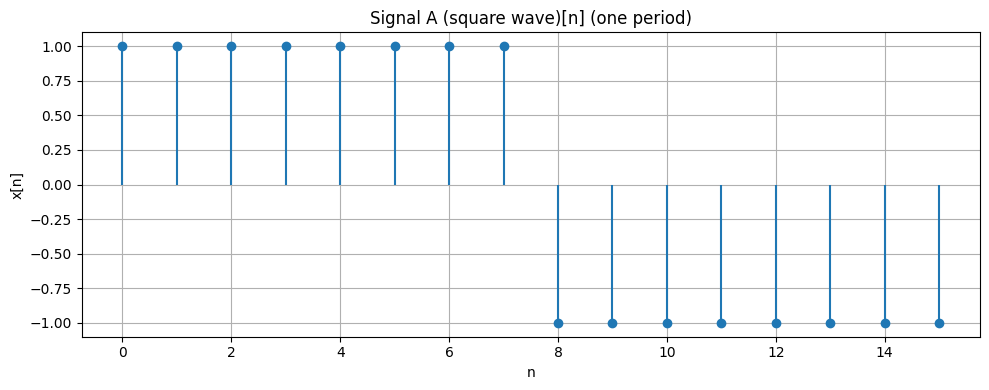

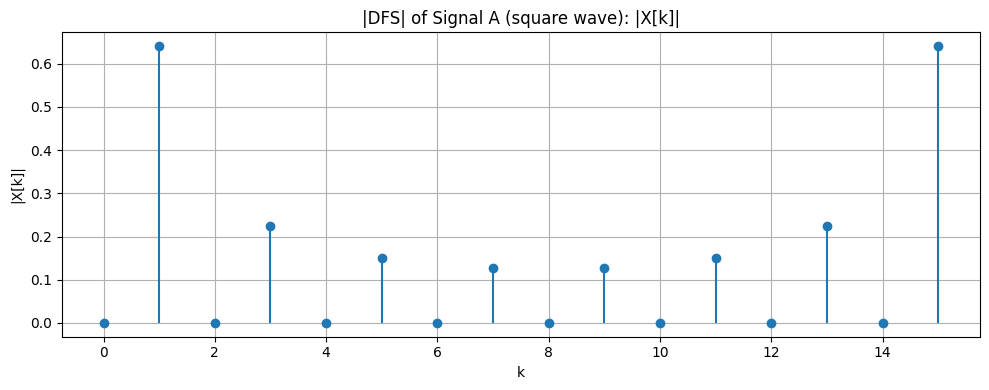

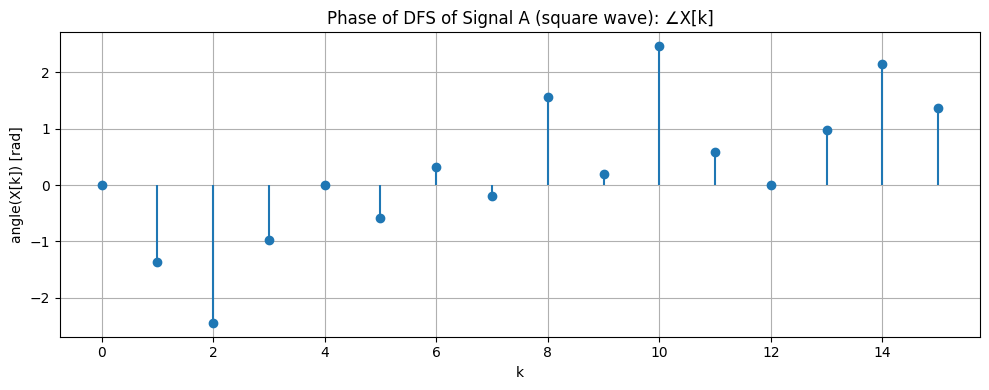

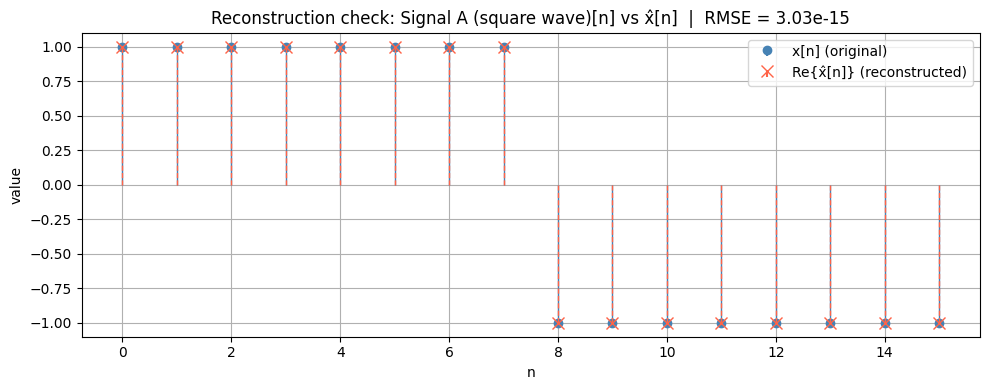

Signal B (triangle wave): N=32, RMSE=2.823999e-15


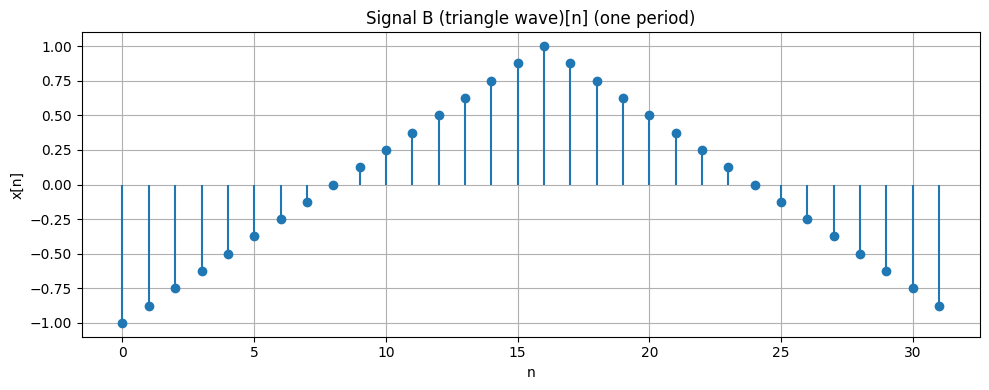

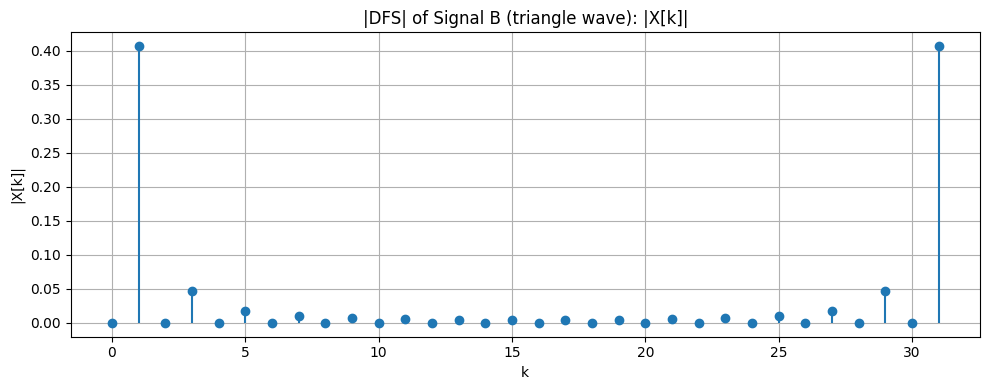

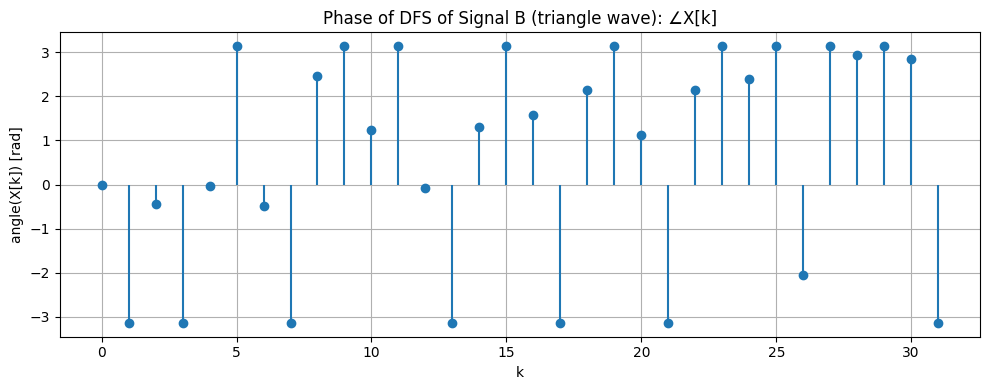

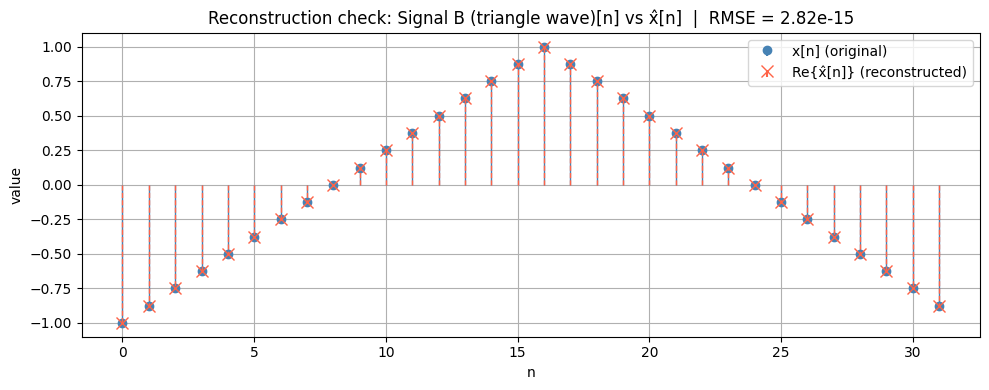

Signal C (sum of sinusoids): N=64, RMSE=7.332764e-15


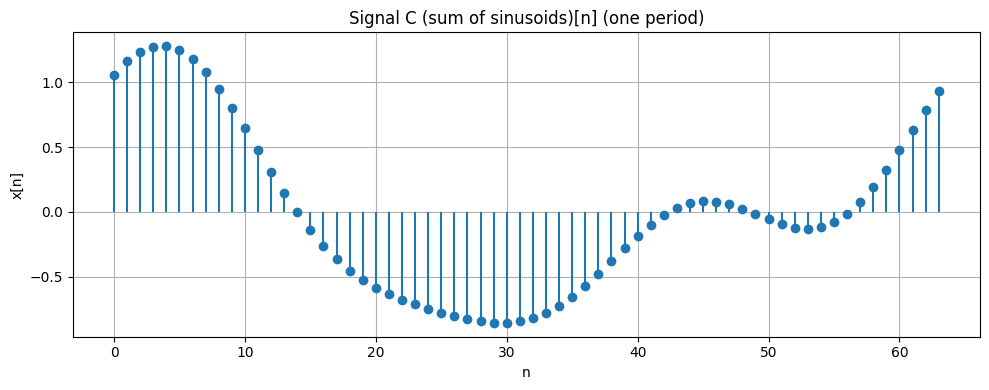

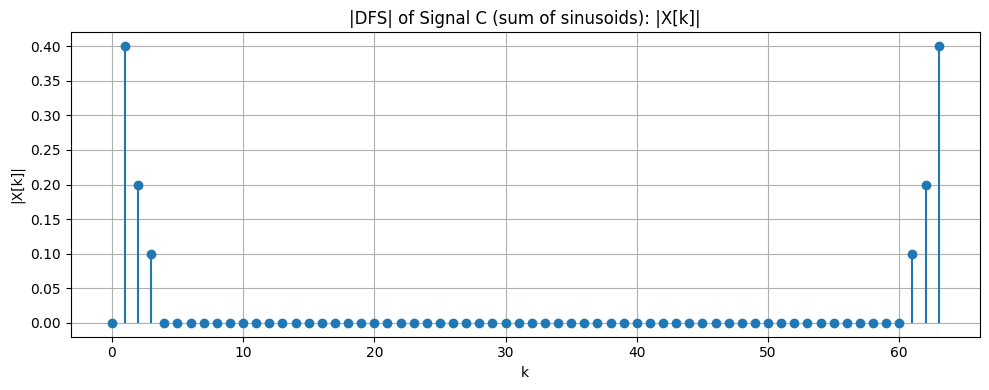

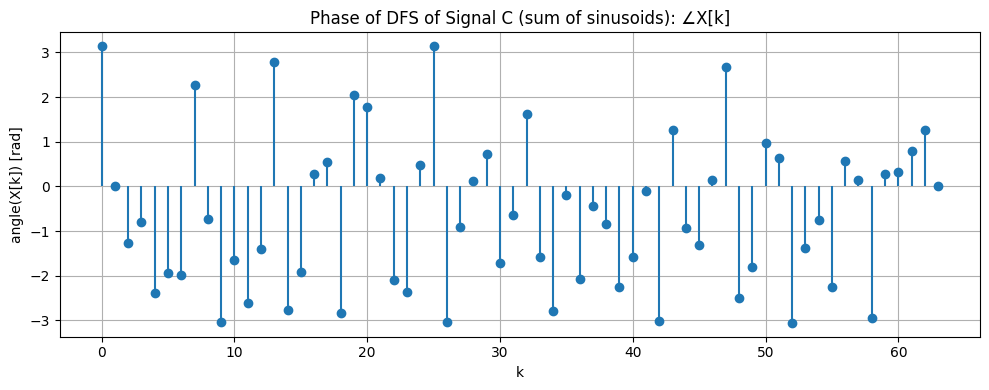

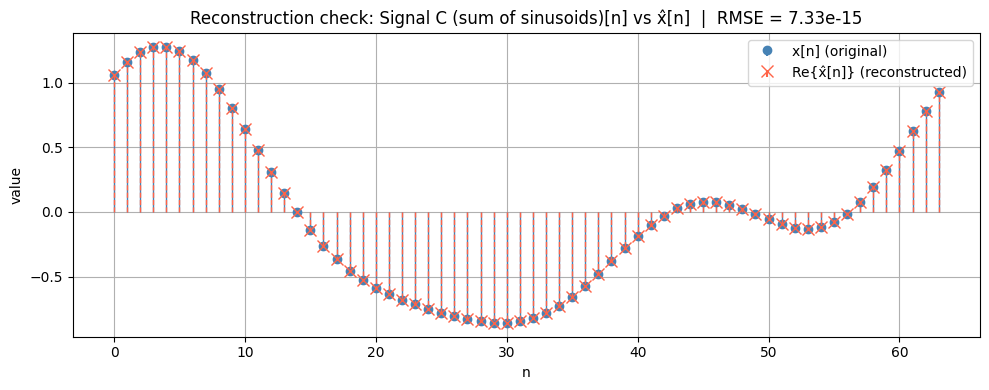

In [9]:
# === Plotting helper ===
def analyze_signal(x, name="x"):
    """Compute DFS, reconstruct, plot, and print RMSE for one period."""
    x = np.asarray(x)
    N = len(x)
    n = np.arange(N)

    # --- DFS / IDFS ---
    X = dfs(x)
    x_hat = idfs(X)

    # --- Error ---
    e = rmse(x, x_hat)
    print(f"{name}: N={N}, RMSE={e:.6e}")

    # --- Plot 1: time domain signal ---
    plt.figure()
    plt.stem(n, np.real(x), basefmt=" ")
    plt.title(f"{name}[n] (one period)")
    plt.xlabel("n")
    plt.ylabel("x[n]")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- Plot 2: magnitude spectrum ---
    k = np.arange(N)
    plt.figure()
    plt.stem(k, np.abs(X), basefmt=" ")
    plt.title(f"|DFS| of {name}: |X[k]|")
    plt.xlabel("k")
    plt.ylabel("|X[k]|")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- Plot 3: phase spectrum ---
    plt.figure()
    plt.stem(k, np.angle(X), basefmt=" ")
    plt.title(f"Phase of DFS of {name}: ∠X[k]")
    plt.xlabel("k")
    plt.ylabel("angle(X[k]) [rad]")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- Plot 4: reconstruction comparison ---
    plt.figure()
    markerline1, stemlines1, baseline1 = plt.stem(
        n, np.real(x), basefmt=" ", label="x[n] (original)"
    )
    plt.setp(markerline1, marker='o', color='steelblue')
    plt.setp(stemlines1, color='steelblue', linewidth=1)

    markerline2, stemlines2, baseline2 = plt.stem(
        n, np.real(x_hat), basefmt=" ", label="Re{x̂[n]} (reconstructed)"
    )
    plt.setp(markerline2, marker='x', color='tomato', markersize=8)
    plt.setp(stemlines2, color='tomato', linewidth=1, linestyle='--')

    plt.title(f"Reconstruction check: {name}[n] vs x̂[n]  |  RMSE = {e:.2e}")
    plt.xlabel("n")
    plt.ylabel("value")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Note on imaginary parts
    max_imag = np.max(np.abs(np.imag(x_hat)))
    if max_imag > 1e-10:
        print(f"  ⚠ Max imaginary part of x̂: {max_imag:.2e}  (numerical noise — using Re{{x̂}})")

    return X, x_hat


# === TODO 4: Run analysis for A, B, C ===
XA, xA_hat = analyze_signal(xA, name="Signal A (square wave)")
XB, xB_hat = analyze_signal(xB, name="Signal B (triangle wave)")
XC, xC_hat = analyze_signal(xC, name="Signal C (sum of sinusoids)")


## Short reflection (write your answers here)

For each signal:

- How many coefficients (roughly) are “dominant” in magnitude?
- Does the phase look structured or noisy? Why?
- If you keep only the largest M coefficients (optional extension), what happens in reconstruction?

*(Write 2–4 sentences per signal.)*


"""
## Short reflection

### Señal A — Onda Cuadrada (N=16)
La onda cuadrada solo tiene coeficientes distintos de cero en las frecuencias
impares (k=1, 3, 5, ...). Esto tiene sentido porque una onda cuadrada es brusca
y necesita muchas frecuencias para representar sus cambios abruptos. Entre más
alta la frecuencia, menos importante es su coeficiente (decae como 1/k). El RMSE
es prácticamente cero (≈ 10⁻¹⁵), lo que significa que la reconstrucción es perfecta.

### Señal B — Onda Triangular (N=32)
Al igual que la cuadrada, la triangular solo usa frecuencias impares, pero como
es una señal más suave (sin cambios bruscos), sus coeficientes decaen mucho más
rápido (como 1/k²). Esto significa que con pocos armónicos ya se puede aproximar
bien la señal. El RMSE es prácticamente cero (≈ 10⁻¹⁵), confirmando reconstrucción
perfecta con los N=32 coeficientes.

### Señal C — Suma de Sinusoides (N=64)
Esta es la más sencilla de entender: como la señal está hecha exactamente de 3
frecuencias (k=1, 2 y 3), solo esos coeficientes son distintos de cero. Todo lo
demás vale cero. Las fases de esos coeficientes reflejan exactamente los desfases
+0.3 y -0.8 que definimos en la señal. El RMSE es prácticamente cero (≈ 10⁻¹⁵).
"""